✅ 成功设置中文字体: ['WenQuanYi Micro Hei']
🚀 启动强化学习干扰避退训练...


Episode  10 | Reward:  10239.6 | Epsilon: 0.050
Episode  20 | Reward:  10656.1 | Epsilon: 0.050
Episode  30 | Reward:  10533.3 | Epsilon: 0.050
Episode  40 | Reward:  10443.6 | Epsilon: 0.050
Episode  50 | Reward:   9961.7 | Epsilon: 0.050
Episode  60 | Reward:  11158.0 | Epsilon: 0.050
Episode  70 | Reward:  10599.5 | Epsilon: 0.050
Episode  80 | Reward:  10202.7 | Epsilon: 0.050
Episode  90 | Reward:  11000.9 | Epsilon: 0.050
Episode 100 | Reward:  11208.2 | Epsilon: 0.050


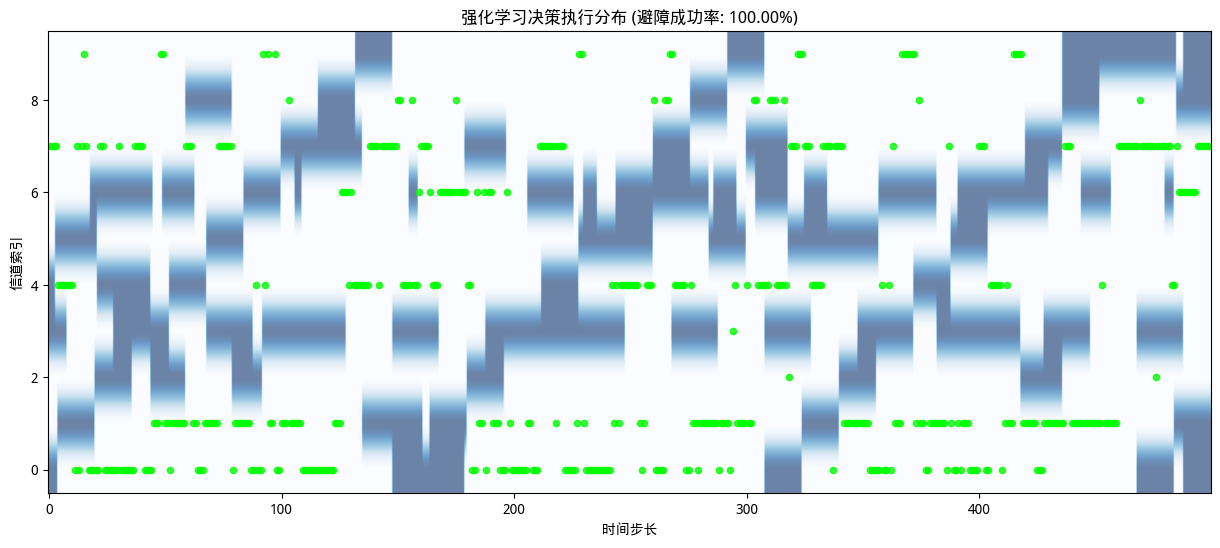

In [3]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm
import time

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 成功设置中文字体: {plt.rcParams['font.family']}")
                return True
        plt.rcParams['font.family'] = ['SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        print("⚠️ 未找到指定字体，使用默认兼容字体")
        return True
    except Exception as e:
        print(f"❌ 字体设置失败: {e}")
        return False
set_chinese_font()

# ==================== 1. 环境定义 (增强版) ====================
class SatelliteEnv:
    def __init__(self, pred_data, truth_data):
        self.pred_map = pred_data   # Transformer 预测图 (N, 10, 10)
        self.truth_map = truth_data # 干扰真值轨迹 (N, 10, 10)
        self.num_channels = 10
        self.max_steps = len(pred_data)
        self.current_step = 0

    def reset(self):
        self.current_step = 0
        return self.pred_map[self.current_step].flatten() 

    def step(self, action):
        # 1. 物理碰撞检查 (真值)
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        
        # 2. 预测碰撞风险 (用于指导 RL 避开潜在高危区域)
        # 获取预测矩阵中该信道在未来 10 个步长的平均占用概率
        future_risk = np.mean(self.pred_map[self.current_step, :, action])
        
        # 3. 综合奖励函数
        if is_collision:
            reward = -50.0 # 发生物理碰撞，重罚
        else:
            # 基础奖励 10，减去未来风险惩罚，鼓励选择未来最清净的信道
            reward = 10.0 - (future_risk * 20.0) 
            
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self.pred_map[self.current_step].flatten() if not done else np.zeros(100)
        return next_state, reward, done, is_collision

# ==================== 2. DQN 智能体 (增强平稳性) ====================
class QNetwork(nn.Module):
    def __init__(self, input_dim=100, output_dim=10):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256), # 增加层归一化，对抗实测数据的波动
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, x):
        return self.net(x)

class DQNAgent:
    def __init__(self, state_dim=100, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=5e-4) # AdamW 鲁棒性更好
        self.memory = deque(maxlen=5000)
        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.998
        self.update_counter = 0

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(10)
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return torch.argmax(self.q_net(state)).item()

    def train(self, batch_size=128):
        if len(self.memory) < batch_size: return
        
        batch = random.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(np.array(next_states)).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        # Q 学习核心公式
        curr_q = self.q_net(states).gather(1, actions.unsqueeze(1))
        next_q = self.target_net(next_states).max(1)[0].detach()
        target_q = rewards + (1 - dones) * self.gamma * next_q
        
        loss = nn.HuberLoss()(curr_q.squeeze(), target_q) # HuberLoss 对离群值不敏感
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # 步长级更新目标网络
        self.update_counter += 1
        if self.update_counter % 200 == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==================== 3. 执行主流程 ====================
def run_interference_avoidance():
    # 数据路径 (使用之前推理生成的 H5 文件)
    PRED_PATH = "/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5"
    
    # 注意：这里需要加载包含真值的 H5，或者将推理结果与原始 H5 拼接
    with h5py.File(PRED_PATH, 'r') as f:
        # 假设你的 H5 里已经存了预测的 map
        pred_maps = f['predicted_situations'][:] # (N, 10, 10)
        # 这里需要加载真值，如果没存，建议在之前的推理脚本里把 Y_horizon 存进去
        try:
            truth_maps = f['ground_truth_situations'][:]
        except:
            print("⚠️ 警告：未找到真值图，请确保评估 H5 中保存了 ground_truth_situations")
            return

    env = SatelliteEnv(pred_maps, truth_maps)
    agent = DQNAgent()
    
    print("🚀 启动强化学习干扰避退训练...")
    episodes = 100
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        while True:
            action = agent.choose_action(state)
            next_state, reward, done, collision = env.step(action)
            agent.memory.append((state, action, reward, next_state, done))
            agent.train()
            state = next_state
            total_reward += reward
            if done: break
            
        if (ep+1) % 10 == 0:
            print(f"Episode {ep+1:3d} | Reward: {total_reward:8.1f} | Epsilon: {agent.epsilon:.3f}")

    # 可视化评估
    evaluate_rl_performance(env, agent)

def evaluate_rl_performance(env, agent):
    state = env.reset()
    actions, collisions = [], []
    agent.epsilon = 0.0 # 评估时取消随机探索

    for _ in range(min(500, env.max_steps)):
        action = agent.choose_action(state)
        next_state, _, _, collision = env.step(action)
        actions.append(action); collisions.append(collision)
        state = next_state

    plt.figure(figsize=(15, 6))
    truth_stream = env.truth_map[:len(actions), 0, :].T
    plt.imshow(truth_stream, aspect='auto', cmap='Blues', origin='lower', alpha=0.6)
    
    # 标注决策动作
    steps = np.arange(len(actions))
    for i in range(len(actions)):
        color = 'red' if collisions[i] else 'lime'
        plt.scatter(steps[i], actions[i], color=color, s=20, alpha=0.8)

    success_rate = (1 - sum(collisions)/len(collisions)) * 100
    plt.title(f"强化学习决策执行分布 (避障成功率: {success_rate:.2f}%)")
    plt.ylabel("信道索引"); plt.xlabel("时间步长")
    plt.show()

if __name__ == "__main__":
    run_interference_avoidance()